# TailorTom - ATS Resume Optimizer

This notebook demonstrates how to optimize your LaTeX resume for Applicant Tracking Systems (ATS) using DSPy and GPT-5-mini.

## Two-Phase Optimization Strategy

**Phase 1: ATS Keyword Integration**
- Focuses solely on integrating keywords from job descriptions
- Content-first approach - prioritizes keyword relevance
- No length constraints during this phase

**Phase 2: Length Reduction (if needed)**
- Only runs if resume exceeds target page count after Phase 1
- Simple condensation techniques (no whitespace optimization)
- Reduces resume to fit within target pages

## Features
- **ATS Keyword Optimization**: Incorporates relevant keywords from job descriptions
- **One-Page Guarantee**: Two-phase approach ensures your resume fits on one page
- **Diff Visualization**: See exactly what changed
- **PDF Export**: Get both `.tex` and `.pdf` outputs


## 1. Setup


In [111]:
%load_ext autoreload
%autoreload 2

import sys
import time
import logging
import base64
from IPython.display import HTML, display, IFrame
from pathlib import Path

# Add backend to path for imports
backend_path = Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

# Load environment variables from .env file
from dotenv import load_dotenv
load_dotenv("../.env")

print("Setup complete!")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete!


In [112]:
# Import TailorTom modules
from tailor_tom.config import settings
from tailor_tom.optimizer import (
    ResumeOptimizerPipeline,
    configure_dspy,
    optimize_resume,
)
from tailor_tom.latex_compiler import compile_latex, validate_latex, save_pdf, save_latex
from tailor_tom.diff_utils import (
    generate_unified_diff,
    generate_pdf_diff_html,
    generate_pdf_image_comparison_html,
    generate_annotated_pdf_comparison_html,
    summarize_changes,
)

# Configure logging to see debug/info messages
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    datefmt='%H:%M:%S'
)

# Configure DSPy with GPT-5-mini
configure_dspy()
print(f"DSPy configured with model: {settings.model_name}")


15:18:47 - tailor_tom.optimizer - INFO - Configuring DSPy with model: openai/gpt-5-mini, max_tokens: 16000, temperature: 1.0


DSPy configured with model: openai/gpt-5-mini


## 2. Load Your Resume

Load your LaTeX resume from a file. Update the path below to point to your resume.


In [113]:
# Path to your LaTeX resume
RESUME_PATH = Path("../main.tex")

# Load resume content
if RESUME_PATH.exists():
    resume_latex = RESUME_PATH.read_text(encoding="utf-8")
    print(f"Loaded resume from {RESUME_PATH}")
    print(f"Length: {len(resume_latex):,} characters, {len(resume_latex.splitlines())} lines")
else:
    print(f"Resume file not found: {RESUME_PATH}")
    print("Please update RESUME_PATH to point to your LaTeX resume.")
    resume_latex = None


Loaded resume from ../main.tex
Length: 15,922 characters, 278 lines


In [114]:
if resume_latex:
    is_valid, error = validate_latex(resume_latex)
    if is_valid:
        print("LaTeX syntax looks valid!")
    else:
        print(f"LaTeX validation warning: {error}")
        print("The optimization will still attempt to run.")


LaTeX syntax looks valid!


In [115]:
if resume_latex:
    print("Compiling original resume...")
    original_compile = compile_latex(resume_latex)
    
    if original_compile.success:
        print(f"Original resume compiles successfully!")
        print(f"Pages: {original_compile.page_count}")
    else:
        print(f"Compilation failed: {original_compile.error_message}")


Compiling original resume...
Original resume compiles successfully!
Pages: 1


## 3. Job Description

Paste the job description you want to optimize for. The more detailed, the better!


In [116]:
# Paste your job description here
# 
# Instructions:
# 1. Copy your job description from the job posting
# 2. Paste it between the triple quotes below (replace the empty string)
# 3. The job description can be multi-line - just paste it as-is
# 4. Run this cell

job_description = """
Machine Learning Intern, 2026 Summer U.S.
Interns | San Francisco, United States | Remote, Remote |

Apply for this job
Working at Atlassian
Atlassians have the flexibility to work where they can collaborate most effectively with their team, whether at home, one of our global offices, or both.

As a distributed-first company, all interviews are conducted virtually. We hire in any country where we have a legal entity. Learn how we work at go.atlassian.com/distributed.

Your Future Org

Atlassian’s Intern program combines hands-on technical training, professional growth opportunities, dedicated mentorship, and strong social connections. This holistic approach empowers students to hit the ground running and sets them up for a successful and impactful career at Atlassian!

This role is located in San Francisco. You must be willing and able to work within 50 miles of our San Francisco office to qualify. Housing support will be provided.

This position is not eligible for F1 and J1 students. It is not available for any work sponsorship.

Your future team

At Atlassian, our machine learning teams tackle business and product challenges across the company. Collaborating with stakeholders in Growth, GTM, Product, Finance, Design and Sales, we deliver machine learning infrastructure and model applications. Our teams, comprised of ML engineers and system engineers, foster collaboration, knowledge sharing, and individual growth. They operate nimbly, emphasizing speed from conceptualization to initial output while maintaining a strong focus on business impact. This role offers a unique chance to work in a collaborative environment and implement cutting-edge machine learning techniques, including search/recommendation engines, GenAI applications, LLM fine-tuning, prompt engineering, RAG optimizations, and more.


Focus on Machine Learning applications and ideas for recommendation and personalization

Build machine learning models and work on Generative AI projects

Translate business problems into technical solutions


Pursuing a masters or bachelors degree in a quantitative subject (Mathematics, Computer Science, Statistics, Machine Learning, Operations Research, or relevant work experience)

Experience writing software with minimal bugs in Python, Scala, Kotlin or Spark; SQL experience a bonus

Experience building machine learning models in academic coursework or related industry intern experience

Able to commit to a 12 week full-time (40hrs/week) program during Summer 2026

Currently enrolled in a full-time masters degree program and returning to the program after the completion of the internship, graduating by June 2027

Compensation

At Atlassian, we strive to design equitable, explainable, and competitive compensation programs. To support this goal, the baseline of our range is higher than that of the typical market range, but in turn we expect to hire most candidates near this baseline. Base pay within the range is ultimately determined by a candidate's skills, expertise, or experience. In the United States, we have three geographic pay zones. For this role, our current base pay ranges for new hires in each zone are:

Zone A: $54/hr - $61/hr

Zone B: $49/hr - $55/hr

Zone C: $45/hr - $51/hr

This role may also be eligible for benefits, bonuses, commissions, and equity.

Please visit go.atlassian.com/payzones for more information on which locations are included in each of our geographic pay zones. However, please confirm the zone for your specific location with your recruiter.

Benefits and Perks
Atlassian offers a wide range of perks and benefits designed to support you, your family and to help you engage with your local community. Our offerings include health and wellbeing resources, paid volunteer days, and so much more. To learn more, visit Atlassian Internships: Students and New Grads | Atlassian.

About Atlassian
At Atlassian, we're motivated by a common goal: to unleash the potential of every team. Our software products help teams all over the planet and our solutions are designed for all types of work. Team collaboration through our tools makes what may be impossible alone, possible together.

We believe that the unique contributions of all Atlassians create our success. To ensure that our products and culture continue to incorporate everyone's perspectives and experience, we never discriminate based on race, religion, national origin, gender identity or expression, sexual orientation, age, or marital, veteran, or disability status. All your information will be kept confidential according to EEO guidelines.

To provide you the best experience, we can support with accommodations or adjustments at any stage of the recruitment process. Simply inform our Recruitment team during your conversation with them.

To learn more about our culture and hiring process, visit go.atlassian.com/crh.
""".strip()

if not job_description:
    print("⚠️ Job description is empty. Please paste the job description between the triple quotes above and run this cell again.")
else:
    print(f"✅ Job description loaded: {len(job_description):,} characters")
    print(f"   Preview: {job_description[:100]}...")


✅ Job description loaded: 4,872 characters
   Preview: Machine Learning Intern, 2026 Summer U.S.
Interns | San Francisco, United States | Remote, Remote |
...


## 4. Run Optimization

This will:
1. Optimize your resume for ATS keywords
2. Compile to PDF and check page count
3. Condense if needed (up to 3 iterations)
4. Return the optimized resume


In [117]:
# Run the optimization pipeline

if resume_latex and job_description:
    print("🚀 Starting optimization...")
    print(f"Model: {settings.model_name}")
    print(f"Max iterations: {settings.max_iterations}")
    print(f"Target pages: {settings.target_pages}")
    print()
    
    start_time = time.time()
    result = optimize_resume(
        resume_latex=resume_latex,
        job_description=job_description,
    )
    elapsed_time = time.time() - start_time
    
    print()
    if result.success:
        print(f"✅ Optimization complete!")
        print(f"Iterations: {result.iterations}")
        print(f"Final page count: {result.page_count}")
        print(f"⏱️  Total time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
    else:
        print(f"⚠️ Optimization completed with warnings")
        print(f"Error: {result.error_message}")
        print(f"Iterations: {result.iterations}")
        print(f"⏱️  Total time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")
else:
    print("❌ Please load your resume and job description first.")
    result = None


15:18:48 - tailor_tom.optimizer - INFO - Configuring DSPy with model: openai/gpt-5-mini, max_tokens: 16000, temperature: 1.0
15:18:48 - tailor_tom.optimizer - INFO - Starting resume optimization pipeline - Phase 1: ATS Keyword Optimization
15:18:48 - tailor_tom.optimizer - INFO - Phase 1: Integrating ATS keywords from job description...


🚀 Starting optimization...
Model: openai/gpt-5-mini
Max iterations: 4
Target pages: 1


PHASE 1: ATS KEYWORD OPTIMIZATION
JOB_DESCRIPTION (length: 4872 chars):
Machine Learning Intern, 2026 Summer U.S.
Interns | San Francisco, United States | Remote, Remote |

Apply for this job
Working at Atlassian
Atlassians have the flexibility to work where they can collaborate most effectively with their team, whether at home, one of our global offices, or both.

As a distributed-first company, all interviews are conducted virtually. We hire in any country where we have a legal entity. Learn how we work at go.atlassian.com/distributed.

Your Future Org

Atlassian’...



15:20:33 - tailor_tom.optimizer - INFO - Generated output filename: Ryan_Amiri_Atlassian.pdf
15:20:33 - tailor_tom.optimizer - WARNING - Phase 1 LaTeX structure validation failed: LaTeX structure was modified (only \item content should change)
15:20:33 - tailor_tom.optimizer - INFO - Compiling Phase 1 result to PDF...
15:20:34 - tailor_tom.optimizer - INFO - Phase 1 complete: 2 page(s)
15:20:34 - tailor_tom.optimizer - INFO - Phase 2: Page reduction needed (2 pages > 1 target)
15:20:34 - tailor_tom.optimizer - INFO - Phase 2 iteration 1/4
15:20:34 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FULL Item text: '3.95/4.0 GPA | Candidate for Bachelor of Science in Computer Science'
15:20:34 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Found 1 spans on last line
15:20:34 - tailor_tom.layout_analyzer - INFO -   Span 1: x0=74.6pt, x1=392.1pt, width=317.6pt, FULL text: '3.95/4.0 GPA — Candidate for Bachelor of Science in Computer Science'
15:2


PHASE 2: PAGE REDUCTION
Current: 2 page(s), Target: 1 page(s)



15:20:36 - tailor_tom.optimizer - INFO - Found 18 qualifying bullets to condense
15:22:08 - tailor_tom.optimizer - INFO - Compiling LaTeX to PDF...
15:22:09 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FULL Item text: '3.95/4.0 GPA | Candidate for Bachelor of Science in Computer Science'
15:22:09 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Found 1 spans on last line
15:22:09 - tailor_tom.layout_analyzer - INFO -   Span 1: x0=74.6pt, x1=392.1pt, width=317.6pt, FULL text: '3.95/4.0 GPA — Candidate for Bachelor of Science in Computer Science'
15:22:09 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Using rightmost span x1=392.1pt
15:22:09 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FINAL VALUES
15:22:09 - tailor_tom.layout_analyzer - INFO -     last_line_x_start=74.6pt
15:22:09 - tailor_tom.layout_analyzer - INFO -     last_line_x_end=392.1pt
15:22:09 - tailor_tom.layout_analyzer - INFO 


PHASE 2: PAGE REDUCTION
Current: 2 page(s), Target: 1 page(s)



15:22:12 - tailor_tom.optimizer - INFO - Found 15 qualifying bullets to condense
15:23:46 - tailor_tom.optimizer - INFO - Compiling LaTeX to PDF...
15:23:47 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FULL Item text: '3.95/4.0 GPA | Candidate for Bachelor of Science in Computer Science'
15:23:47 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Found 1 spans on last line
15:23:47 - tailor_tom.layout_analyzer - INFO -   Span 1: x0=74.6pt, x1=392.1pt, width=317.6pt, FULL text: '3.95/4.0 GPA — Candidate for Bachelor of Science in Computer Science'
15:23:47 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Using rightmost span x1=392.1pt
15:23:47 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FINAL VALUES
15:23:47 - tailor_tom.layout_analyzer - INFO -     last_line_x_start=74.6pt
15:23:47 - tailor_tom.layout_analyzer - INFO -     last_line_x_end=392.1pt
15:23:47 - tailor_tom.layout_analyzer - INFO 


PHASE 2: PAGE REDUCTION
Current: 2 page(s), Target: 1 page(s)



15:23:50 - tailor_tom.optimizer - INFO - Found 14 qualifying bullets to condense
15:25:11 - tailor_tom.optimizer - INFO - Compiling LaTeX to PDF...
15:25:12 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FULL Item text: '3.95/4.0 GPA | Candidate for Bachelor of Science in Computer Science'
15:25:12 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Found 1 spans on last line
15:25:12 - tailor_tom.layout_analyzer - INFO -   Span 1: x0=74.6pt, x1=392.1pt, width=317.6pt, FULL text: '3.95/4.0 GPA — Candidate for Bachelor of Science in Computer Science'
15:25:12 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: Using rightmost span x1=392.1pt
15:25:12 - tailor_tom.layout_analyzer - INFO - [extract_line_metrics] Bullet 1: FINAL VALUES
15:25:12 - tailor_tom.layout_analyzer - INFO -     last_line_x_start=74.6pt
15:25:12 - tailor_tom.layout_analyzer - INFO -     last_line_x_end=392.1pt
15:25:12 - tailor_tom.layout_analyzer - INFO 


✅ Optimization complete!
Iterations: 4
Final page count: 1
⏱️  Total time: 384.98 seconds (6.42 minutes)


## 5. View Changes

See what was changed in your resume.


In [118]:
# Summary of changes
if result and result.optimized_latex:
    print(summarize_changes(result.original_latex, result.optimized_latex))


📊 Change Summary:
  • Lines: 278 → 278 (+0)
  • Added: 0 lines
  • Removed: 0 lines
  • Modified: 20 lines
  • Characters: 15,922 → 15,173 (-4.7%)



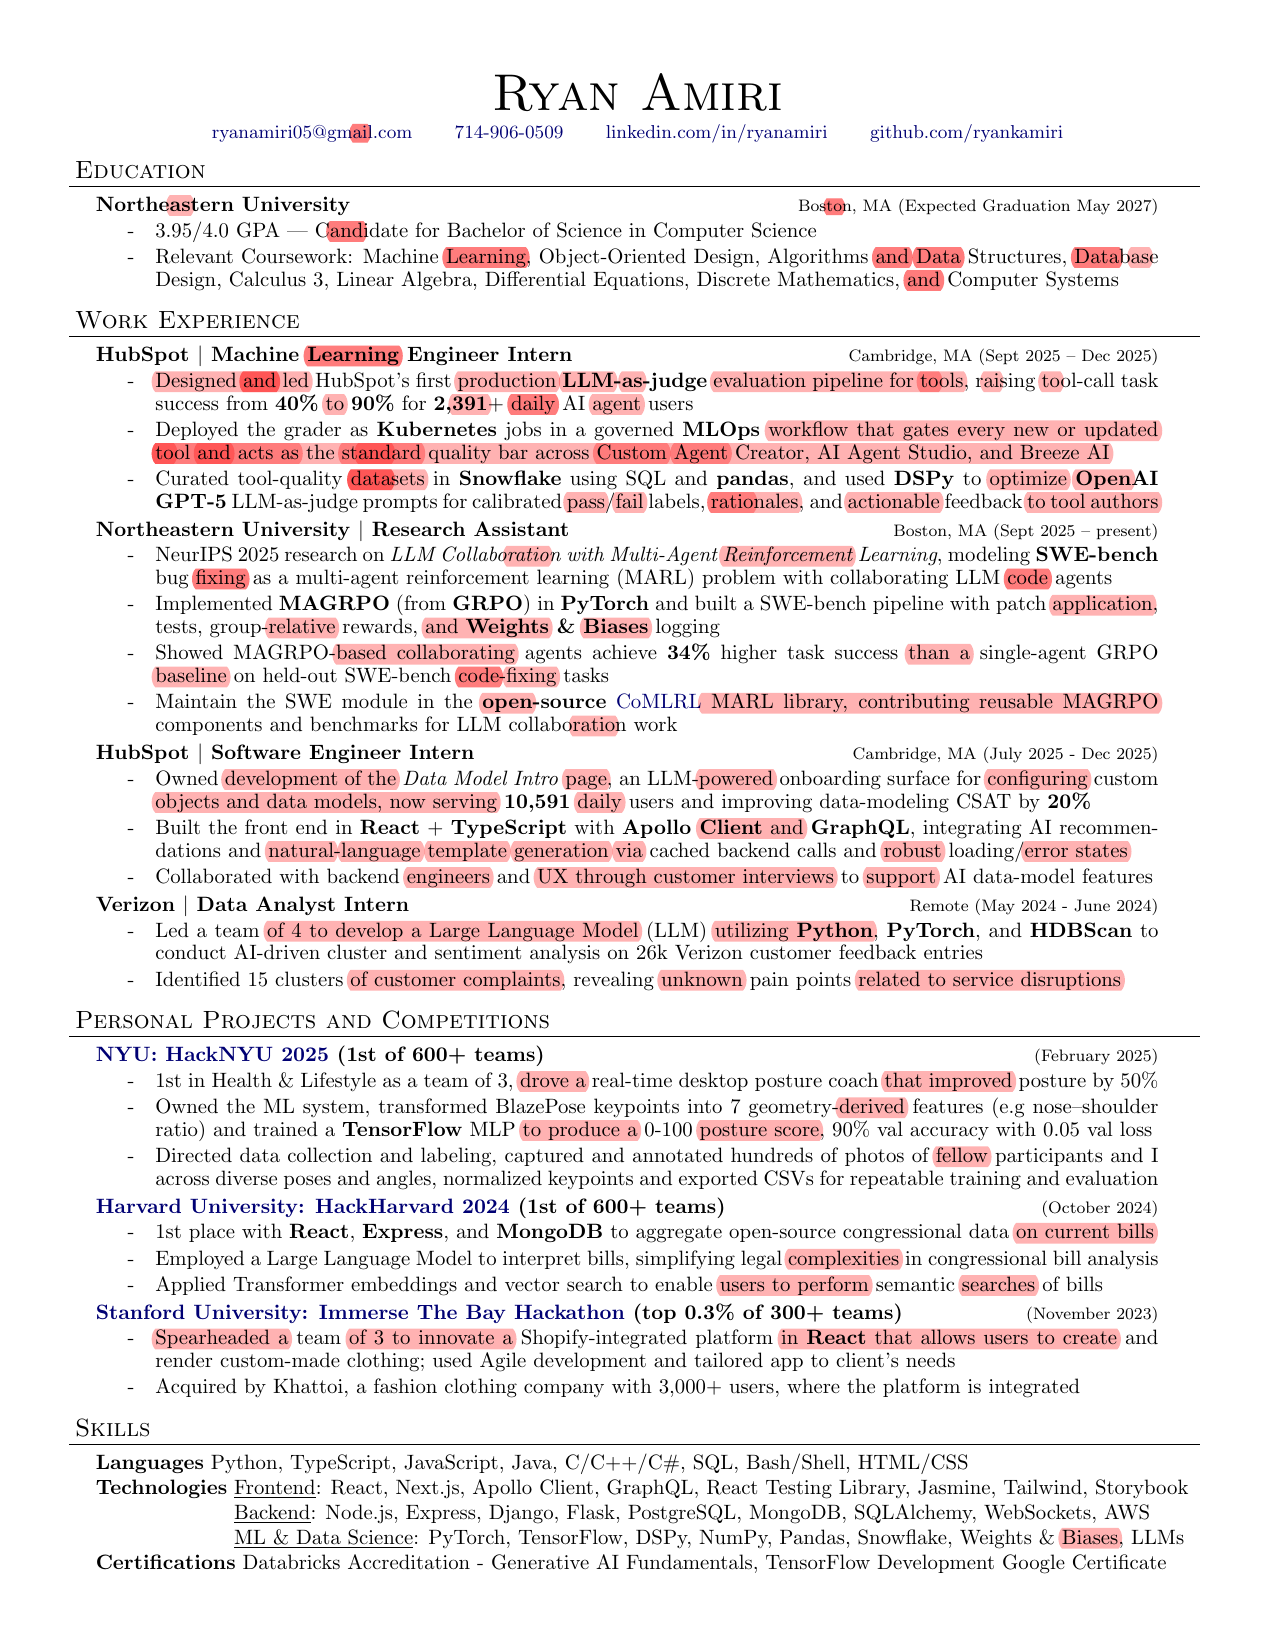
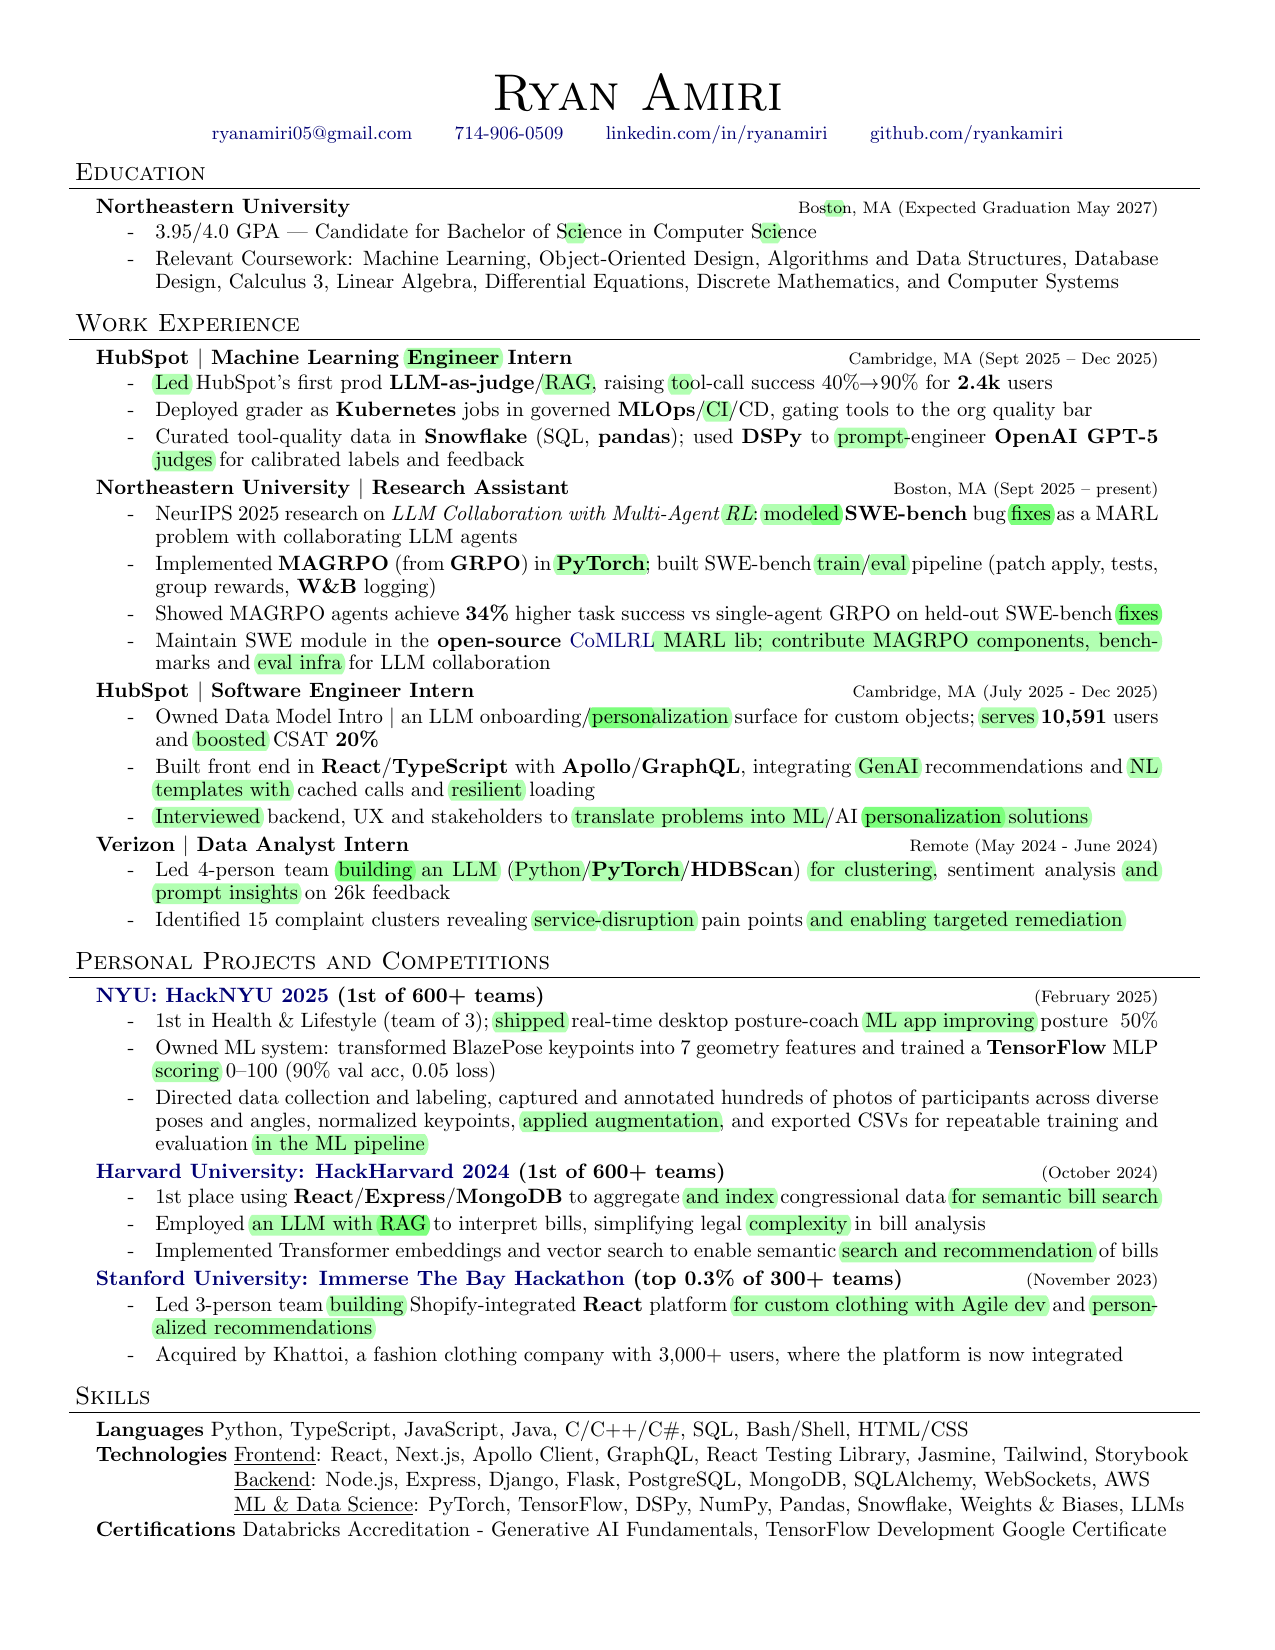

In [119]:
# Annotated PDF comparison - highlights changes directly on the PDFs
# Uses LaTeX source for accurate diff comparison

if result and result.pdf_bytes and resume_latex:
    # Compile original resume to get PDF for comparison
    original_compile = compile_latex(resume_latex)
    
    if original_compile.success and original_compile.pdf_bytes:
        # Generate annotated PDFs with highlighted differences
        # Pass LaTeX source for more accurate diff comparison
        comparison_html = generate_annotated_pdf_comparison_html(
            original_pdf_bytes=original_compile.pdf_bytes,
            optimized_pdf_bytes=result.pdf_bytes,
            original_latex=result.original_latex,
            optimized_latex=result.optimized_latex,
            dpi=150,
        )
        display(HTML(comparison_html))
    else:
        print("⚠️ Could not compile original resume for PDF comparison.")
        if original_compile.error_message:
            print(f"   Error: {original_compile.error_message}")
else:
    print("❌ No optimized PDF available for comparison.")


## 7. Export Results

Save the optimized resume to files.


In [120]:
# Output directory
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

if result and result.optimized_latex:
    # Save LaTeX
    tex_path = OUTPUT_DIR / "optimized_resume.tex"
    save_latex(result.optimized_latex, tex_path)
    print(f"✅ Saved LaTeX: {tex_path}")
    
    # Save PDF with generated filename
    if result.pdf_bytes:
        # Use generated filename if available, otherwise fallback to default
        if result.filename:
            pdf_path = OUTPUT_DIR / result.filename
        else:
            pdf_path = OUTPUT_DIR / "optimized_resume.pdf"
        try:
            save_pdf(result.pdf_bytes, pdf_path)
            # Verify file was saved correctly
            if pdf_path.exists() and pdf_path.stat().st_size > 0:
                print(f"✅ Saved PDF: {pdf_path}")
                print(f"   File size: {pdf_path.stat().st_size:,} bytes")
            else:
                print(f"⚠️ PDF file may not have been saved correctly: {pdf_path}")
        except Exception as e:
            print(f"⚠️ Error saving PDF: {e}")
            print(f"   Attempted path: {pdf_path}")
    
    # Save diff
    diff_path = OUTPUT_DIR / "changes.diff"
    diff = generate_unified_diff(result.original_latex, result.optimized_latex)
    diff_path.write_text(diff, encoding="utf-8")
    print(f"✅ Saved diff: {diff_path}")
else:
    print("❌ No results to export.")


✅ Saved LaTeX: ../output/optimized_resume.tex
✅ Saved PDF: ../output/Ryan_Amiri_Atlassian.pdf
   File size: 118,781 bytes
✅ Saved diff: ../output/changes.diff
